In [1]:
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np

from network import FCN, Layer
from metrics import confusion_matrix, accuracy, plot_losses, summary

I0000 00:00:1785775393.123343   11857 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785775393.123844   11857 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785775393.157633   11857 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785775394.213465   11857 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [2]:
def show_digit(X, y, index):
    plt.imshow(X[index].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {np.argmax(y[index])}")
    plt.axis('off')
    plt.show()

In [3]:
def one_hot(y, classes=10):
    encoded = np.zeros((len(y), classes))
    encoded[np.arange(len(y)), y] = 1
    return encoded

FCN initialized


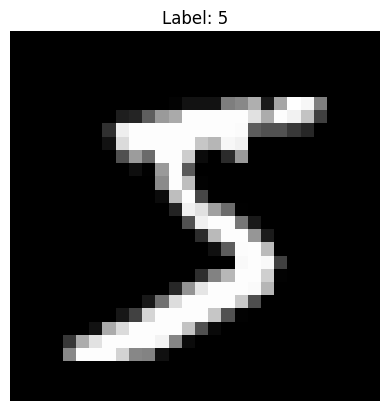

In [4]:
# initialize network with 2 hidden layers
network = FCN([
    Layer(784),
    Layer(128, 'relu'),
    Layer(64, 'relu'),
    Layer(10, 'softmax')
],
learning_rate=0.01,
loss = "cross_entropy")

# load mnist data and split into train and test partitions
(X_train_full, y_train_full), (X_test, y_test) = mnist.load_data()
y_train_full = one_hot(y_train_full)
y_test = one_hot(y_test)

# flatten each image from (28x28) to 784, then normalise to [0,1]
X_train_full = X_train_full.reshape(60000, 784) / 255.0
X_test  = X_test.reshape(10000, 784)  / 255.0

X_train, y_train = X_train_full[:50000], y_train_full[:50000]
X_val, y_val = X_train_full[50000:], y_train_full[50000:]



# test show a digit
show_digit(X_train, y_train, 0)



In [ ]:
losses = network.train(X_train, y_train, X_val, y_val, epochs=1, batch_size=32)

# display some metrics
plot_losses(losses)
summary(network, X_test, y_test)

FCN initialized
Epoch 1/5 - Loss: 0.2876
Epoch 2/5 - Loss: 0.1167
Epoch 3/5 - Loss: 0.0835
Epoch 4/5 - Loss: 0.0644
Epoch 5/5 - Loss: 0.0493
Batch size 1: 97.52%
FCN initialized
Epoch 1/5 - Loss: 0.6675
Epoch 2/5 - Loss: 0.2924
Epoch 3/5 - Loss: 0.2364
Epoch 4/5 - Loss: 0.1972
Epoch 5/5 - Loss: 0.1680
Batch size 8: 95.68%
FCN initialized
Epoch 1/5 - Loss: 1.4061
Epoch 2/5 - Loss: 0.4806
Epoch 3/5 - Loss: 0.3762
Epoch 4/5 - Loss: 0.3358
Epoch 5/5 - Loss: 0.3105
Batch size 32: 92.15%
FCN initialized
Epoch 1/5 - Loss: 1.9868
Epoch 2/5 - Loss: 0.8395
Epoch 3/5 - Loss: 0.5250
Epoch 4/5 - Loss: 0.4310
Epoch 5/5 - Loss: 0.3865
Batch size 64: 90.61%
FCN initialized
Epoch 1/5 - Loss: 2.2559
Epoch 2/5 - Loss: 1.7635
Epoch 3/5 - Loss: 1.0062
Epoch 4/5 - Loss: 0.6921
Epoch 5/5 - Loss: 0.5611
Batch size 128: 87.71%
FCN initialized
Epoch 1/5 - Loss: 2.2905
Epoch 2/5 - Loss: 2.2218
Epoch 3/5 - Loss: 1.9775
Epoch 4/5 - Loss: 1.5222
Epoch 5/5 - Loss: 1.1210
Batch size 256: 79.65%


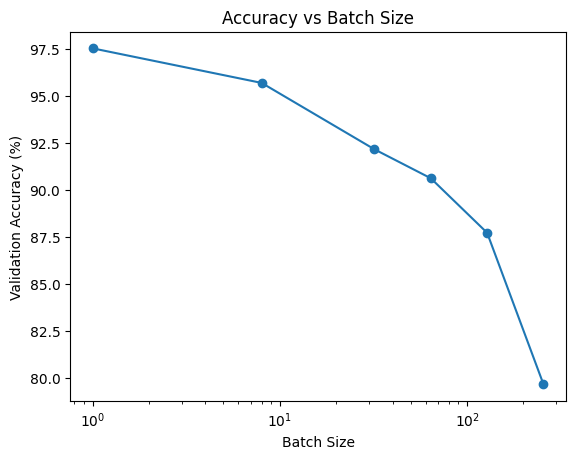

In [ ]:
# testing batch_size
batch_sizes = [1, 8, 32, 64, 128, 256]
results = {}

for bs in batch_sizes:
    model = FCN([
        Layer(784),
        Layer(128, 'relu'),
        Layer(10, 'softmax')
    ], loss='cross_entropy', learning_rate=0.01)
    
    model.train(X_train, y_train, epochs=5, batch_size=bs)
    acc = accuracy(model, X_val, y_val)
    results[bs] = acc
    print(f"Batch size {bs}: {acc:.2f}%")

# plot
print("Batch sizes:", batch_sizes)
plt.plot(list(results.keys()), list(results.values()), marker='o')
plt.xscale('log')
plt.xlabel('Batch Size')
plt.ylabel('Validation Accuracy (%)')
plt.title('Accuracy vs Batch Size')
plt.show()

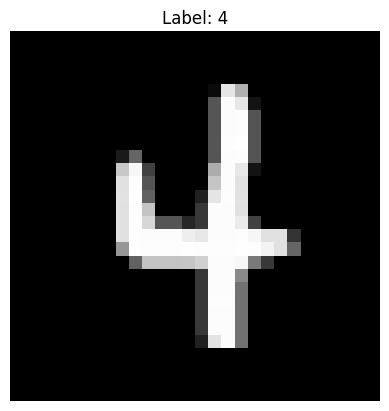

[0.0003 0.0004 0.0253 0.001  0.4456 0.0075 0.0298 0.0732 0.0379 0.379 ]
Prediction: 4


In [6]:
import random

index = random.randint(0, 9999)
show_digit(X_test, y_test, index)
np.set_printoptions(precision=4, suppress=True)
pred = network.predict(X_test[index])
print(pred)
print("Prediction:", np.argmax(pred))